# Data Is Not a Decision — companion notebook

**Diogo Ribeiro** · ESMAD, Instituto Politécnico do Porto · Lead Data Scientist, Mysense.ai
ORCID [0009-0001-2022-7072](https://orcid.org/0009-0001-2022-7072)

Reproduces the simulated case study from the essay *Data Is Not a Decision*: a retailer choosing a
daily order quantity for a perishable product under uncertain demand.

The notebook runs top to bottom with `numpy`, `pandas`, `scipy`, `statsmodels` and `matplotlib`.

**What it covers**

1. The economics of the decision, and why the answer is a quantile
2. The data-generating process
3. Four ordering policies, fitted on 300 days
4. Evaluation on 120 held-out days
5. Whether the improvement is statistically real — paired bootstrap, and replication across seeds
6. How precisely the quantile is estimated, and what estimation error costs
7. **Censored demand**: why this whole exercise can fail silently on real operational data
8. Quantile regression as the pooled alternative to four separate buckets
9. Sensitivity to the shortage cost
10. The essay's figures

**On reproducibility.** The essay's numbers came from a simulation whose parameters were not recorded.
The process below was re-specified from the reported summary statistics — mean demand, stockout
frequency, fill rate, and the four context quantiles — and the seed was chosen so the output lands
close to the published table. Treat the exact euro figures as one draw from a stochastic process,
not as constants; section 5 shows how much they move across draws, which is the point.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

PAPER, INK = "#EDEFEE", "#111A21"
COLD, HOT = "#41708F", "#B23A28"
RULE, MUTE = "#C3C8C7", "#6E7C85"

mpl.rcParams.update({
    "font.family": "Latin Modern Roman", "font.size": 11,
    "axes.facecolor": PAPER, "figure.facecolor": PAPER, "savefig.facecolor": PAPER,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.9,
})
pd.set_option("display.width", 120)
SEED = 50

## 1. The economics, and why the answer is a quantile

Selling price $p$, purchase cost $c$, salvage value $v$ on an unsold unit, and an additional
shortage penalty $b$ on each unit of unmet demand. Realised profit is

$$\Pi(q, D) = p\min(q,D) + v\max(q-D,0) - cq - b\max(D-q,0)$$

Differentiating the expectation with respect to $q$ and setting it to zero,

$$\frac{d\,\mathbb{E}[\Pi]}{dq} = (p+b)\bigl(1-F(q)\bigr) + vF(q) - c = 0
\;\Longrightarrow\;
F(q^\ast) = \frac{p+b-c}{p+b-v} = \frac{C_u}{C_u + C_o}$$

so the optimal order is a **quantile** of the demand distribution, at a level fixed by the relative
cost of the two errors — not the mean, and not a forecast.

In [2]:
P, C, V, B = 15.0, 8.0, 3.0, 2.0          # price, cost, salvage, shortage penalty
CO = C - V                                 # cost of one unit too many
CU = P - C + B                             # cost of one unit too few
ALPHA = CU / (CU + CO)                     # critical service level

print(f"C_o = {CO:.0f}   C_u = {CU:.0f}   alpha = {ALPHA:.4f}")


def profit(q, d):
    q, d = np.asarray(q, float), np.asarray(d, float)
    return P * np.minimum(q, d) + V * np.maximum(q - d, 0) - C * q - B * np.maximum(d - q, 0)

C_o = 5   C_u = 9   alpha = 0.6429


## 2. The data-generating process

420 consecutive days. Demand shifts with two conditions the buyer observes *before* ordering —
weekend and promotion — plus a mild temperature effect, with an interaction that makes promotional
weekends more than the sum of their parts.

$$\mu_t = 56.1 + 7\,\mathrm{wknd}_t + 17\,\mathrm{promo}_t + 11\,(\mathrm{wknd}\times\mathrm{promo})_t
+ 0.4\,(\mathrm{temp}_t - 18), \qquad D_t = \lfloor \mu_t + \varepsilon_t \rceil,\;
\varepsilon_t \sim N(0, 7.91^2)$$

Everything downstream treats this as unknown.

In [3]:
BASE, SIG, P_PROMO = 56.1, 7.91, 0.17


def simulate(seed=SEED, n=420):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    weekend = np.isin(t % 7, [5, 6]).astype(int)
    promo = (rng.random(n) < P_PROMO).astype(int)
    temp = 18 + 5 * np.sin(2 * np.pi * t / 365) + rng.normal(0, 3, n)
    mu = BASE + 7 * weekend + 17 * promo + 11 * weekend * promo + 0.4 * (temp - 18)
    demand = np.clip(np.round(mu + rng.normal(0, SIG, n)), 0, None).astype(int)
    df = pd.DataFrame(dict(day=t, dow=t % 7, weekend=weekend, promo=promo,
                           temperature=temp.round(1), demand=demand))
    df["context"] = (np.where(df.promo, "promotional ", "ordinary ")
                     + np.where(df.weekend, "weekend", "weekday"))
    return df


df = simulate()
train, test = df.iloc[:300].copy(), df.iloc[300:].copy()
print(f"train {len(train)} days, mean demand {train.demand.mean():.1f}")
print(f"test  {len(test)} days, mean demand {test.demand.mean():.1f}"
      f"  (range {test.demand.min()}\u2013{test.demand.max()})")
df.head()

train 300 days, mean demand 61.7
test  120 days, mean demand 62.4  (range 38–101)


,day,dow,weekend,promo,temperature,demand,context
0,0,0,0,0,15.2,47,ordinary weekday
1,1,1,0,0,16.8,63,ordinary weekday
2,2,2,0,0,17.4,56,ordinary weekday
3,3,3,0,0,15.0,59,ordinary weekday
4,4,4,0,0,19.3,43,ordinary weekday


In [4]:
train.groupby("context").demand.agg(
    days="size", mean="mean",
    cost_quantile=lambda s: np.ceil(np.quantile(s, ALPHA))).round(1)

,days,mean,cost_quantile
context,,,
ordinary weekday,172,55.6,59.0
ordinary weekend,69,63.2,65.0
promotional weekday,43,73.7,76.0
promotional weekend,16,88.8,93.0


Note the last column against the second: on every context the cost-sensitive quantile sits **above**
the mean, because a shortage costs €9 and a leftover €5. Note also `days` for promotional weekends —
that thin cell is revisited in section 6.

## 3. Four policies, fitted on the first 300 days

In [5]:
q_global = float(np.ceil(np.quantile(train.demand, ALPHA)))
q_mean = float(np.round(train.demand.mean()))
q_ctx = train.groupby("context").demand.apply(
    lambda s: float(np.ceil(np.quantile(s, ALPHA)))).to_dict()

policies = {
    "Manager rule":         np.full(len(test), 60.0),
    "Average demand":       np.full(len(test), q_mean),
    "Global quantile":      np.full(len(test), q_global),
    "Contextual quantile":  test.context.map(q_ctx).to_numpy(float),
}

print(f"average-demand order : {q_mean:.0f}")
print(f"global quantile order: {q_global:.0f}")
for k, v in q_ctx.items():
    print(f"  {k:<22}: {v:.0f}")

average-demand order : 62
global quantile order: 64
  ordinary weekday      : 59
  ordinary weekend      : 65
  promotional weekday   : 76
  promotional weekend   : 93


## 4. Evaluation on the 120 held-out days

In [6]:
d = test.demand.to_numpy(float)

rows = []
for name, q in policies.items():
    pi = profit(q, d)
    rows.append({
        "policy": name,
        "total profit": pi.sum(),
        "avg daily": pi.mean(),
        "fill rate %": np.minimum(q, d).sum() / d.sum() * 100,
        "stockout days %": (d > q).mean() * 100,
        "avg leftovers": np.maximum(q - d, 0).mean(),
        "waste rate %": np.maximum(q - d, 0).sum() / q.sum() * 100,
    })

results = pd.DataFrame(rows).set_index("policy").round(
    {"total profit": 0, "avg daily": 2, "fill rate %": 1,
     "stockout days %": 1, "avg leftovers": 2, "waste rate %": 1})
results

,total profit,avg daily,fill rate %,stockout days %,avg leftovers,waste rate %
policy,,,,,,
Manager rule,43718.0,364.32,90.4,51.7,3.64,6.1
Average demand,44198.0,368.32,92.0,44.2,4.64,7.5
Global quantile,44454.0,370.45,93.4,39.2,5.78,9.0
Contextual quantile,47093.0,392.44,95.7,44.2,4.02,6.3


The average-demand rule barely moves the needle: the sample mean is close to the manager's 60, so
replacing judgement with an average changes almost nothing. The global quantile buys availability by
ordering more. The contextual policy wins by *distinguishing situations that call for different
actions*, not by forecasting any single day accurately.

## 5. Is the improvement real?

Both policies face the *same* realised demand path, so the comparison is paired. Working with the
120 daily differences removes the demand variation common to both and isolates the effect of the
ordering rule.

In [7]:
diff = profit(policies["Contextual quantile"], d) - profit(policies["Manager rule"], d)

rng = np.random.default_rng(0)
boot = np.array([diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(20_000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
t, p = stats.ttest_1samp(diff, 0)

print(f"mean daily advantage : \u20ac{diff.mean():.2f}")
print(f"95% bootstrap CI     : [\u20ac{lo:.2f}, \u20ac{hi:.2f}]")
print(f"paired t-test        : t = {t:.2f}, p = {p:.2e}")
print(f"days contextual loses: {(diff < 0).sum()} of {len(diff)}")

mean daily advantage : €28.12
95% bootstrap CI     : [€16.99, €40.21]
paired t-test        : t = 4.72, p = 6.49e-06
days contextual loses: 37 of 120


The advantage survives the test here. It is worth seeing *where* it comes from, because a gain
concentrated in one thin context is a far more fragile result than one spread across the week.

In [8]:
by_ctx = (pd.DataFrame({"context": test.context.to_numpy(), "gain": diff})
          .groupby("context").gain.agg(days="size", mean_gain="mean", total_gain="sum")
          .round(2).sort_values("total_gain", ascending=False))
by_ctx["share of total %"] = (by_ctx.total_gain / by_ctx.total_gain.sum() * 100).round(1)
by_ctx

,days,mean_gain,total_gain,share of total %
context,,,,
promotional weekend,6,241.00,1446.0,42.8
promotional weekday,11,124.91,1374.0,40.7
ordinary weekend,29,19.41,563.0,16.7
ordinary weekday,74,-0.11,-8.0,-0.2


### Replication across seeds

A single 120-day evaluation is one draw. Re-running the whole pipeline on fresh seeds shows how much
the headline percentage moves for reasons that have nothing to do with the method.

In [9]:
def run_once(seed):
    dd = simulate(seed)
    tr, te = dd.iloc[:300], dd.iloc[300:]
    qc = tr.groupby("context").demand.apply(
        lambda s: float(np.ceil(np.quantile(s, ALPHA)))).to_dict()
    dt = te.demand.to_numpy(float)
    base = profit(np.full(len(te), 60.0), dt).sum()
    ctxp = profit(te.context.map(qc).to_numpy(float), dt).sum()
    glob = profit(np.full(len(te), float(np.ceil(np.quantile(tr.demand, ALPHA)))), dt).sum()
    return ctxp / base - 1, glob / base - 1


reps = pd.DataFrame([run_once(s) for s in range(200)],
                    columns=["contextual vs manager", "global vs manager"])
print((reps * 100).describe(percentiles=[.05, .5, .95]).round(2).to_string())
print(f"\ncontextual beats manager in {(reps.iloc[:, 0] > 0).mean():.1%} of replications")
print(f"global     beats manager in {(reps.iloc[:, 1] > 0).mean():.1%} of replications")

       contextual vs manager  global vs manager
count                 200.00             200.00
mean                    6.59               1.04
std                     1.72               0.73
min                     3.02              -1.27
5%                      4.10              -0.08
50%                     6.45               1.02
95%                     9.74               2.35
max                    11.92               2.83

contextual beats manager in 100.0% of replications
global     beats manager in 93.5% of replications


The contextual policy is reliably better; the *size* of the gain swings by several percentage points
across draws. Any single reported figure — including the one in the essay — should be read as a point
in that distribution rather than as the return on the method.

## 6. How precisely is the quantile estimated?

The asymptotic standard error of a sample quantile is

$$\mathrm{SE}(\hat q_\alpha) \approx \frac{1}{f(q_\alpha)}\sqrt{\frac{\alpha(1-\alpha)}{n}}$$

which for the thin promotional-weekend cell is large enough to matter.

In [10]:
z = stats.norm.ppf(ALPHA)
dens_at_q = stats.norm.pdf(z) / SIG          # density at the quantile, normal within-cell

se = []
for ctx, n in train.context.value_counts().items():
    analytic = np.sqrt(ALPHA * (1 - ALPHA) / n) / dens_at_q
    s = train.loc[train.context == ctx, "demand"].to_numpy()
    r = np.random.default_rng(1)
    bs = np.array([np.quantile(s[r.integers(0, n, n)], ALPHA) for _ in range(4000)])
    se.append(dict(context=ctx, n=n, order=q_ctx[ctx],
                   analytic_SE=analytic, bootstrap_SE=bs.std(),
                   ci_low=np.percentile(bs, 2.5), ci_high=np.percentile(bs, 97.5)))

pd.DataFrame(se).set_index("context").round(1)

,n,order,analytic_SE,bootstrap_SE,ci_low,ci_high
context,,,,,,
ordinary weekday,172,59.0,0.8,1.0,57.0,61.0
ordinary weekend,69,65.0,1.2,0.9,64.0,67.7
promotional weekday,43,76.0,1.5,1.4,74.0,80.0
promotional weekend,16,93.0,2.5,1.8,86.6,95.6


The promotional-weekend order is quoted to the unit but is really known to within several units. The
consoling half of the story is that the expected cost of a small quantile error is **second order**:
near the optimum the expected-profit curve is flat, with curvature $(C_u + C_o)f(q^\ast)$, so the
excess cost of being $\delta$ units off is about

$$\tfrac{1}{2}(C_u + C_o)\,f(q^\ast)\,\delta^2$$

In [11]:
delta = np.arange(0, 13)
approx = 0.5 * (CU + CO) * dens_at_q * delta ** 2

# exact, by Monte Carlo on the promotional-weekend cell
r = np.random.default_rng(3)
sim_d = np.clip(np.round(BASE + 7 + 17 + 11 + r.normal(0, SIG, 400_000)), 0, None)
q_star = np.quantile(sim_d, ALPHA)
exact = np.array([profit(q_star, sim_d).mean() - profit(q_star + k, sim_d).mean() for k in delta])

pd.DataFrame({"error (units)": delta, "quadratic approx (\u20ac/day)": approx.round(2),
              "exact (\u20ac/day)": exact.round(2)}).set_index("error (units)").T

error (units),0,1,2,3,4,5,6,7,8,9,10,11,12
quadratic approx (€/day),0.0,0.33,1.32,2.97,5.28,8.25,11.89,16.18,21.13,26.74,33.02,39.95,47.54
exact (€/day),0.0,0.32,1.27,2.80,4.86,7.41,10.37,13.72,17.39,21.34,25.52,29.88,34.40


Roughly €3.50 a day at ±4 units — about €420 over a 120-day period, against a measured gain an order
of magnitude larger. Estimation noise erodes the advantage without destroying it. Worth computing
rather than assuming.

## 7. Censored demand — the failure that does not announce itself

Everything above used `demand`. A real retailer records **sales**. When the shelf empties the two
diverge, and sales are a right-censored observation: all that is learned is that demand was *at
least* the quantity stocked.

Under the manager's rule the shelf emptied on roughly half of all days. Replay the history as an
operator would actually have observed it.

In [12]:
q_hist = np.full(len(train), 60.0)                       # what the manager ordered
sales = np.minimum(train.demand.to_numpy(float), q_hist)  # what the system recorded
uncensored = train.demand.to_numpy(float) <= q_hist       # True = a real demand observation

print(f"censored observations: {(~uncensored).mean():.1%} of the training history")
print(f"naive quantile of SALES        : {np.ceil(np.quantile(sales, ALPHA)):.0f}")
print(f"quantile of true DEMAND        : {np.ceil(np.quantile(train.demand, ALPHA)):.0f}")

censored observations: 51.7% of the training history
naive quantile of SALES        : 60
quantile of true DEMAND        : 64


The naive estimate on sales returns 60 — the manager's own order quantity. Sales can never exceed
what was stocked, so their distribution has a hard ceiling with a large point mass sitting on it.
Run on real data, the entire method would have recommended the incumbent policy and reported
statistical support for doing so. **A fixed ordering rule manufactures the evidence for its own
continuation.**

The textbook remedy is the Kaplan–Meier product-limit estimator, which reconstructs the demand
distribution from censored observations. It is worth being precise about what it can and cannot do.

In [13]:
def kaplan_meier_cdf(obs, event):
    'Product-limit estimate of F for right-censored observations.'
    obs, event = np.asarray(obs, float), np.asarray(event, bool)
    vals = np.unique(obs[event])
    surv, out = 1.0, []
    for v in vals:
        at_risk = (obs >= v).sum()
        events = ((obs == v) & event).sum()
        surv *= (1 - events / at_risk)
        out.append((v, 1 - surv))
    return pd.DataFrame(out, columns=["value", "F_hat"])


km = kaplan_meier_cdf(sales, uncensored)
reach = km.F_hat.max()
print(f"largest CDF value Kaplan-Meier can identify: F({km.value.max():.0f}) = {reach:.3f}")
print(f"target quantile level                      : {ALPHA:.3f}")
print("identified?" , "yes" if reach >= ALPHA else "NO - the quantile lies above the censoring point")

largest CDF value Kaplan-Meier can identify: F(60) = 0.483
target quantile level                      : 0.643
identified? NO - the quantile lies above the censoring point


With a *constant* order quantity the upper tail is not merely hard to estimate, it is **not
identified**: no estimator recovers a quantile that sits above the point at which every observation
was truncated. Kaplan–Meier helps only when the historical order quantities varied enough to observe
demand above the level of interest.

That variation has to be created deliberately. Below, the same history is replayed with the manager
occasionally ordering above his habit — the kind of variation a pilot generates on purpose.

In [14]:
r = np.random.default_rng(11)
q_varied = np.where(r.random(len(train)) < 0.30, r.integers(75, 101, len(train)), 60.0)
sales_v = np.minimum(train.demand.to_numpy(float), q_varied)
unc_v = train.demand.to_numpy(float) <= q_varied

km_v = kaplan_meier_cdf(sales_v, unc_v)
q_km = km_v.loc[km_v.F_hat >= ALPHA, "value"].min()

print(f"censored observations : {(~unc_v).mean():.1%}")
print(f"naive quantile of sales      : {np.ceil(np.quantile(sales_v, ALPHA)):.0f}")
print(f"Kaplan-Meier quantile        : {q_km:.0f}")
print(f"true-demand quantile (target): {np.ceil(np.quantile(train.demand, ALPHA)):.0f}")

censored observations : 37.7%
naive quantile of sales      : 60
Kaplan-Meier quantile        : 65
true-demand quantile (target): 64


Exploration is not a side effect of a pilot; it is what makes the upper tail learnable at all.
Before applying any of this, establish whether the demand column is demand or sales — and if it is
sales, whether the historical order quantities ever varied.

## 8. Quantile regression instead of four buckets

Splitting the sample into four cells is a good teaching device and a poor estimator: it discards the
continuous covariate, estimates four related quantities independently, and collapses as conditions
multiply. Quantile regression estimates $Q_D(\alpha \mid x)$ directly by minimising the asymmetric
pinball loss

$$\rho_\alpha(u) = u\bigl(\alpha - \mathbf{1}\{u<0\}\bigr)$$

which *is* the newsvendor cost function up to scale when $\alpha = C_u/(C_u+C_o)$. The economics and
the estimator are the same object.

In [15]:
import statsmodels.formula.api as smf

qr = smf.quantreg("demand ~ weekend * promo + temperature", train).fit(q=ALPHA)
print(qr.summary().tables[1])

policies["Quantile regression"] = np.ceil(qr.predict(test).to_numpy())
pi_qr = profit(policies["Quantile regression"], d)
print(f"\nquantile-regression policy: total \u20ac{pi_qr.sum():,.0f}, "
      f"fill {np.minimum(policies['Quantile regression'], d).sum()/d.sum():.1%}, "
      f"stockout {(d > policies['Quantile regression']).mean():.1%}")

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        54.4406      2.566     21.213      0.000      49.390      59.491
weekend           7.3861      1.437      5.139      0.000       4.558      10.215
promo            17.0792      1.736      9.836      0.000      13.662      20.496
weekend:promo     7.4356      3.305      2.250      0.025       0.931      13.940
temperature       0.2475      0.131      1.892      0.059      -0.010       0.505

quantile-regression policy: total €47,353, fill 96.3%, stockout 40.8%


In [16]:
comparison = pd.DataFrame({
    name: {"total profit": profit(q, d).sum(),
           "vs manager %": (profit(q, d).sum() / profit(policies["Manager rule"], d).sum() - 1) * 100}
    for name, q in policies.items()}).T.round(2)
comparison

,total profit,vs manager %
Manager rule,43718.0,0.00
Average demand,44198.0,1.10
Global quantile,44454.0,1.68
Contextual quantile,47093.0,7.72
Quantile regression,47353.0,8.31


Pooling buys little here because the data-generating process is exactly the saturated interaction the
four buckets already encode. The advantage appears when conditions multiply — add holidays and a
competitor flag and the bucket count goes to sixteen while the regression gains two coefficients.

## 9. Sensitivity to the shortage cost

$b$ is the parameter nobody can measure and everyone must choose. It should never be reported as a
point estimate; report the recommendation as a function of it and let the argument happen over the
range.

In [17]:
grid_b = np.arange(0, 11, 1.0)
sens = []
for b in grid_b:
    a = (P - C + b) / ((P - C + b) + CO)
    row = {"b (\u20ac)": b, "alpha": round(a, 3)}
    row.update({k: int(np.ceil(np.quantile(train.loc[train.context == k, "demand"], a)))
                for k in sorted(q_ctx)})
    sens.append(row)

sens = pd.DataFrame(sens).set_index("b (\u20ac)")
sens

,alpha,ordinary weekday,ordinary weekend,promotional weekday,promotional weekend
b (€),,,,,
0.0,0.583,58,65,76,92
1.0,0.615,58,65,76,93
2.0,0.643,59,65,76,93
3.0,0.667,60,66,76,93
4.0,0.688,60,66,76,93
5.0,0.706,61,67,77,93
6.0,0.722,61,67,78,93
7.0,0.737,61,68,79,93
8.0,0.750,62,68,79,93


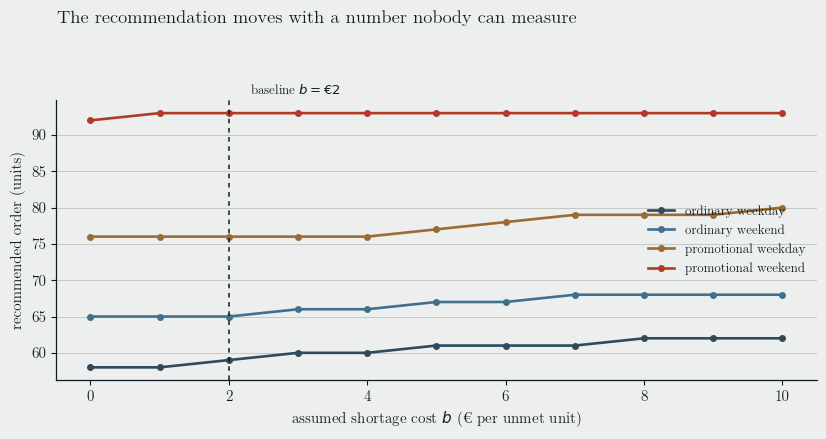

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
for col, c in zip(sorted(q_ctx), ["#2E4A5C", COLD, "#9A6B33", HOT]):
    ax.plot(sens.index, sens[col], marker="o", ms=4, lw=1.9, color=c, label=col)
ax.axvline(B, color=INK, lw=1.1, ls=(0, (3, 3)))
ax.annotate("baseline $b=\u20ac2$", xy=(B, ax.get_ylim()[1]), xytext=(B + 0.3, 97),
            fontsize=9.5, color=INK, va="top")
ax.set_xlabel("assumed shortage cost $b$ (\u20ac per unmet unit)")
ax.set_ylabel("recommended order (units)")
ax.grid(axis="y", color=RULE, lw=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9.5, loc="center right")
fig.suptitle("The recommendation moves with a number nobody can measure",
             fontsize=13.5, x=0.075, ha="left", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

If the recommendation is stable across the range management considers plausible, the argument about
$b$ need not be settled. If it is not stable, the analysis has correctly identified that the
organisation has an unresolved question about its own priorities.

## 10. The essay's figure

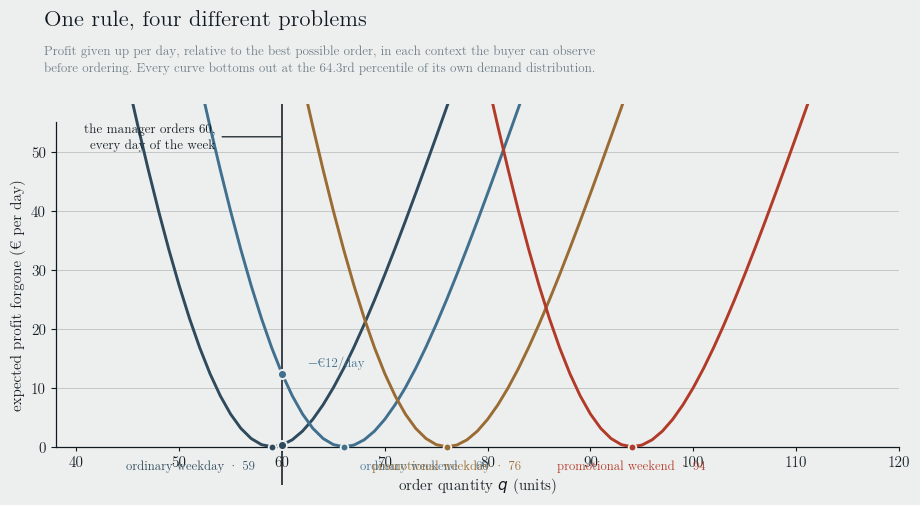

In [19]:
CONTEXTS = {"ordinary weekday": (0, 0, "#2E4A5C"), "ordinary weekend": (1, 0, COLD),
            "promotional weekday": (0, 1, "#9A6B33"), "promotional weekend": (1, 1, HOT)}
LAB = {"ordinary weekday": (-1.6, "right"), "ordinary weekend": (1.6, "left"),
       "promotional weekday": (0, "center"), "promotional weekend": (0, "center")}


def draws(weekend, promo, n=400_000, seed=7):
    r = np.random.default_rng(seed)
    temp = 18 + 5 * np.sin(r.uniform(0, 2 * np.pi, n)) + r.normal(0, 3, n)
    mu = BASE + 7 * weekend + 17 * promo + 11 * weekend * promo + 0.4 * (temp - 18)
    return np.clip(np.round(mu + r.normal(0, SIG, n)), 0, None)


grid = np.arange(38, 121, 1.0)
i60 = int(np.searchsorted(grid, 60.0))
fig, ax = plt.subplots(figsize=(9.4, 5.6))

for label, (wk, pr, col) in CONTEXTS.items():
    dd = draws(wk, pr)
    curve = np.array([profit(q, dd).mean() for q in grid])
    regret = curve.max() - curve
    star = grid[regret.argmin()]
    dx, ha = LAB[label]
    ax.plot(grid, regret, color=col, lw=2.1, zorder=3, solid_capstyle="round")
    ax.plot([star], [0], "o", ms=5.5, color=col, mec=PAPER, mew=1.3, zorder=6)
    ax.annotate(f"{label} \u00b7 {star:.0f}", xy=(star, 0), xytext=(star + dx, -2.2),
                color=col, fontsize=9.3, ha=ha, va="top")
    ax.plot([60], [regret[i60]], "o", ms=6.5, color=col, mec=PAPER, mew=1.4, zorder=6)
    if regret[i60] > 1.5:
        ax.annotate(f"\u2212\u20ac{regret[i60]:.0f}/day", xy=(62.5, regret[i60] + 0.8),
                    color=col, fontsize=9.4, ha="left", va="bottom")

ax.axvline(60, color=INK, lw=1.15, zorder=2)
ax.annotate("the manager orders 60,\nevery day of the week", xy=(60, 52.5), xytext=(53.5, 52.5),
            fontsize=9.6, color=INK, ha="right", va="center", linespacing=1.4,
            arrowprops=dict(arrowstyle="-", color=INK, lw=0.9, shrinkA=3, shrinkB=1))
ax.set_xlabel("order quantity $q$ (units)")
ax.set_ylabel("expected profit forgone (\u20ac per day)")
ax.set_xlim(38, 120); ax.set_ylim(-6.5, 58)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.spines["bottom"].set_position(("data", 0)); ax.spines["left"].set_bounds(0, 55)
ax.grid(axis="y", color=RULE, lw=0.7); ax.set_axisbelow(True); ax.tick_params(axis="x", length=3)
fig.text(0.065, 0.965, "One rule, four different problems", fontsize=16.5, va="top")
fig.text(0.065, 0.902, "Profit given up per day, relative to the best possible order, in each "
         "context the buyer can observe\nbefore ordering. Every curve bottoms out at the 64.3rd "
         "percentile of its own demand distribution.",
         fontsize=9.5, va="top", color=MUTE, linespacing=1.5)
fig.subplots_adjust(left=0.078, right=0.975, top=0.795, bottom=0.115)
plt.show()

## Notes and references

The single-period inventory model is due to Arrow, Harris and Marschak (1951). The connection between
the newsvendor quantile and the pinball loss of quantile regression comes from Koenker and Bassett
(1978). The feature-based formulation, which solves the decision problem in one step rather than
forecasting and then optimising, is Ban and Rudin (2019); Bertsimas and Kallus (2020) give the general
predictive-to-prescriptive framing, and Elmachtoub and Grigas (2022) train against decision regret
directly. On censored demand, Huh, Levi, Rusmevichientong and Orlin (2011) build adaptive policies on
the Kaplan–Meier estimator, and Sachs and Minner (2014) extend it to the data-driven newsvendor.

---

*Diogo Ribeiro — ESMAD, Instituto Politécnico do Porto · [dfr@esmad.ipp.pt](mailto:dfr@esmad.ipp.pt)
· [ORCID 0009-0001-2022-7072](https://orcid.org/0009-0001-2022-7072) ·
[github.com/diogoribeiro7](https://github.com/diogoribeiro7)*